In [1]:
# Importing required libraries and evaluation functions
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Loading dataset
df = pd.read_csv("../data/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Shape: (284807, 31)

Class Distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


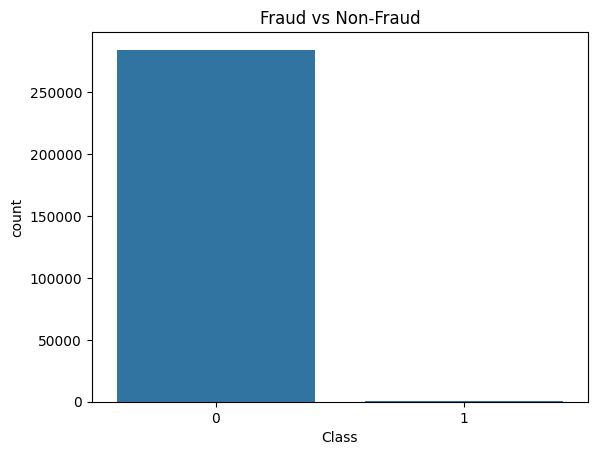

In [3]:
# Printing the shape of the dataset (number of rows and columns)
# This gives a quick idea of dataset size
print("Shape:", df.shape)

# Displaying class distribution (fraud vs non-fraud) in percentage
# Helps us understand how imbalanced the dataset is
print("\nClass Distribution:")
print(df['Class'].value_counts(normalize=True))

# Visualizing the distribution of fraud and non-fraud transactions
# This makes it easier to see the imbalance clearly
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

In [4]:
# Initializing the StandardScaler to normalize feature values
# This ensures that large transaction amounts do not dominate the model

scaler = StandardScaler()

# Scaling the 'Amount' column so that it has mean = 0 and standard deviation = 1
# This helps improve model performance, especially for algorithms sensitive to feature scale
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [5]:
# Creating a new feature 'hour' from the 'Time' column
# This converts time (in seconds) into hours to capture when transactions occur
# Fraud patterns can vary depending on time of day
df['hour'] = df['Time'] // 3600

# Applying log transformation to the 'Amount' column
# This reduces the impact of very large transaction values and makes the data more balanced
df['amount_log'] = np.log1p(df['Amount'])

In [6]:
# Separating input features (X) and target variable (y)
# 'Class' is the label where 1 = fraud and 0 = non-fraud
X = df.drop('Class', axis=1)
y = df['Class']

# Splitting the dataset into training and testing sets
# - 80% data for training, 20% for testing
# - random_state ensures reproducibility
# - stratify=y keeps the same fraud ratio in both sets (very important for imbalanced data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# Initializing SMOTE to handle class imbalance
# It generates synthetic samples for the minority class (fraud cases)
smote = SMOTE(random_state=42)

# Applying SMOTE only on the training data
# This helps the model learn fraud patterns better without affecting the test set
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Printing class distribution before and after applying SMOTE
# This helps verify that the dataset is now balanced
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


In [8]:
# Initializing Logistic Regression model
# This will act as our baseline model to compare with advanced models later
baseline_model = LogisticRegression()

# Training the model on the balanced training data (after applying SMOTE)
# This helps the model learn both fraud and non-fraud patterns
baseline_model.fit(X_train_res, y_train_res)

# Predicting class labels (0 = non-fraud, 1 = fraud) on the test data
y_pred_base = baseline_model.predict(X_test)

# Predicting probabilities for the positive class (fraud)
# These probabilities are useful for evaluation metrics like ROC-AUC
y_prob_base = baseline_model.predict_proba(X_test)[:,1]

# Printing model performance metrics
# Classification report shows precision, recall, and F1-score
print("Baseline Model:\n")
print(classification_report(y_test, y_pred_base))

# ROC-AUC measures how well the model separates fraud and non-fraud cases
print("ROC-AUC:", roc_auc_score(y_test, y_prob_base))

Baseline Model:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.91      0.14        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.57     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9743740525191507


In [9]:
# Initializing XGBoost model with tuned hyperparameters
# - n_estimators: number of trees (more trees → better learning, but slower)
# - max_depth: controls complexity of each tree
# - learning_rate: controls how fast the model learns
# - scale_pos_weight: helps handle class imbalance (fraud cases are rare)
# - random_state: ensures reproducibility
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=10,
    random_state=42
)

# Training the model on balanced training data
# XGBoost learns complex patterns better than baseline models
xgb_model.fit(X_train_res, y_train_res)

# Predicting class labels (fraud / non-fraud)
y_pred_xgb = xgb_model.predict(X_test)

# Predicting probabilities for fraud class
# These probabilities are used for metrics like ROC-AUC and KS
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

# Printing performance metrics of the enhanced model
print("Enhanced Model:\n")
print(classification_report(y_test, y_pred_xgb))

# ROC-AUC shows how well the model distinguishes fraud vs non-fraud
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Enhanced Model:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.63      0.89      0.74        98

    accuracy                           1.00     56962
   macro avg       0.82      0.94      0.87     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.981347188565916


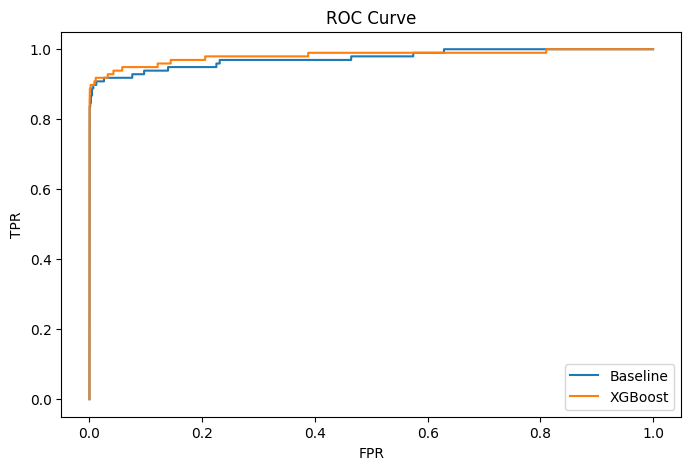

In [10]:
# Calculating ROC curve values for baseline model
# fpr = False Positive Rate, tpr = True Positive Rate
# These values are used to plot the ROC curve
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)

# Calculating ROC curve values for XGBoost model
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Creating a plot to compare both models
plt.figure(figsize=(8,5))

# Plotting ROC curve for baseline model
plt.plot(fpr_base, tpr_base, label="Baseline")

# Plotting ROC curve for XGBoost model
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

# Labeling axes for better understanding
plt.xlabel("FPR")  # False Positive Rate
plt.ylabel("TPR")  # True Positive Rate

# Adding title and legend
plt.title("ROC Curve")
plt.legend()

# Displaying the plot
plt.show()

In [11]:
# Function to calculate KS (Kolmogorov-Smirnov) statistic
# KS measures how well the model separates fraud (event) and non-fraud (non-event) cases
def ks_statistic(y_true, y_prob):

    # Creating a DataFrame with actual labels and predicted probabilities
    df_ks = pd.DataFrame({'y': y_true, 'prob': y_prob})
    
    # Sorting data by predicted probability in descending order
    # This helps analyze how well the model ranks fraud cases at the top
    df_ks = df_ks.sort_values(by='prob', ascending=False)
    
    # Calculating cumulative percentage of fraud cases (events)
    df_ks['cum_event'] = np.cumsum(df_ks['y']) / sum(df_ks['y'])
    
    # Calculating cumulative percentage of non-fraud cases (non-events)
    df_ks['cum_non_event'] = np.cumsum(1 - df_ks['y']) / sum(1 - df_ks['y'])
    
    # KS is the maximum difference between cumulative event and non-event distributions
    ks = max(abs(df_ks['cum_event'] - df_ks['cum_non_event']))
    
    return ks


# Printing KS score to evaluate model performance
# Higher KS means better separation between fraud and non-fraud
print("KS Score:", ks_statistic(y_test, y_prob_xgb))

KS Score: 0.9072355236410828


In [12]:
# Creating a DataFrame with actual labels and predicted probabilities
# This helps in evaluating how well the model ranks fraud cases
df_eval = pd.DataFrame({'y': y_test, 'prob': y_prob_xgb})

# Sorting transactions by predicted probability (highest risk first)
# The model should ideally rank fraud cases at the top
df_eval = df_eval.sort_values(by='prob', ascending=False)

# Selecting top 10% of transactions based on highest predicted risk
top_10 = int(0.1 * len(df_eval))

# Calculating how many actual fraud cases are captured in top 10%
# This metric is very important in fraud detection (focus on high-risk segment)
capture_rate = df_eval.head(top_10)['y'].sum() / df_eval['y'].sum()

# Printing the capture rate
print("Top 10% Capture Rate:", capture_rate)

Top 10% Capture Rate: 0.9489795918367347


In [13]:
# Creating a copy of the test data to simulate a real-world scenario
# This ensures we don’t modify the original test dataset
X_test_shifted = X_test.copy()

# Simulating distribution shift by increasing transaction amounts
# This mimics changes in user behavior or market conditions over time
X_test_shifted['Amount'] = X_test_shifted['Amount'] * 1.5

# Generating predictions on the shifted data
# This helps us check how the model performs when data distribution changes
y_prob_shifted = xgb_model.predict_proba(X_test_shifted)[:,1]

# Evaluating model performance after shift using ROC-AUC
# A drop in score indicates model degradation due to distribution change
print("ROC-AUC After Shift:", roc_auc_score(y_test, y_prob_shifted))

ROC-AUC After Shift: 0.9807724194067047


In [14]:
# Creating a copy of the test dataset
# This is done to avoid modifying the original test data
X_test_shifted = X_test.copy()

# Simulating a change in data distribution by increasing transaction amounts
# This helps mimic real-world scenarios where user behavior changes over time
X_test_shifted['Amount'] = X_test_shifted['Amount'] * 1.5

# Generating predicted probabilities on the shifted data
# Used to check how model performance is affected after the shift
y_prob_shifted = xgb_model.predict_proba(X_test_shifted)[:,1]

# Calculating ROC-AUC score after applying distribution shift
# A decrease in this score indicates that the model performance has degraded
print("ROC-AUC After Shift:", roc_auc_score(y_test, y_prob_shifted))

ROC-AUC After Shift: 0.9807724194067047


In [15]:
# Function to calculate PSI (Population Stability Index)
# PSI is used to measure how much the data distribution has changed over time
def calculate_psi(expected, actual, bins=10):
    
    # Creating equally spaced bins between 0 and 1
    # These bins are used to group probability values
    breakpoints = np.linspace(0, 1, bins + 1)
    
    # Calculating distribution of expected (original) data across bins
    # Dividing by length to convert counts into proportions
    expected_bins = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    
    # Calculating distribution of actual (shifted) data across bins
    actual_bins = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    
    # Applying PSI formula
    # Small constant (1e-6) is added to avoid division by zero
    psi = np.sum((actual_bins - expected_bins) * 
                 np.log((actual_bins + 1e-6) / (expected_bins + 1e-6)))
    
    return psi


# Calculating PSI between original predictions and shifted predictions
# This tells us how much the model output distribution has changed
psi_value = calculate_psi(y_prob_xgb, y_prob_shifted)

# Printing PSI value
print("PSI:", psi_value)

PSI: 0.00015231987241776841


In [16]:
# Importing pickle to save the trained model
# This allows us to reuse the model later without retraining
import pickle

# Saving the trained XGBoost model to a file
# The model can be loaded later for predictions or deployment
pickle.dump(xgb_model, open("../models/pipeline_fraud_model.pkl", "wb"))